# Monte Carlo Simulation Project: New Product Launch Risk Analysis

## 1. Project Overview
A tech company is planning to launch a new smartwatch. While the marketing and production teams have provided estimates, there is significant uncertainty regarding sales volume, pricing flexibility, and fluctuating raw material costs. Instead of relying on a single "best-case" or "worst-case" scenario, we will use a **Monte Carlo Simulation** to model the probability of different profit outcomes.

## 2. The Variables (Input Distributions)
To represent reality, we treat our inputs as probability distributions rather than fixed numbers:

| Variable | Description | Distribution Type | Parameters |
| :--- | :--- | :--- | :--- |
| **Sales Quantity ($N$)** | Number of units sold | **Normal** | $\mu = 10,000$, $\sigma = 2,000$ |
| **Selling Price ($P$)** | Price per unit | **Uniform** | $Min = 150, Max = 200$ |
| **Variable Cost ($C$)** | Production cost per unit | **Triangular** | $Min = 80, Mode = 90, Max = 120$ |
| **Fixed Costs ($F$)** | R&D and Marketing | **Fixed** | $500,000$ (Constant) |

---

## 3. The Mathematical Model
The total profit ($G$) for the product launch is calculated using the following linear equation:

$$G = [N \times (P - C)] - F$$

---

## 4. Simulation Objectives
Your task is to run **10,000 iterations** of this model to answer the following business questions:

1.  **Deterministic vs. Probabilistic:** Calculate the profit using only the "mean" values of the inputs. How does this single-point estimate compare to the average result of the 10,000 simulations?
2.  **Probability of Loss:** What is the probability that the project results in a net loss ($G < 0$)?
3.  **Profit Targets:** What is the probability of achieving a profit greater than **250,000 TL**?
4.  **Risk Assessment:** Identify the **5th and 95th percentiles** of the profit distribution to understand the Value at Risk (VaR).
5.  **Visualization:** Plot a histogram of the profit results and overlay a line representing the break-even point ($G = 0$).

---

### Why this matters:
In a typical regression project, you predict a single value. Here, you are predicting the **entire range of possibilities**. This allows a manager to say: *"We expect to make 400k, but there is a 12% chance we might actually lose money."*ance we might actually lose money."*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# Solution

## 1. Deterministic Way:

In [2]:
np.random.seed(0)

N = 10000
P = 175
C = (80+120+90)/3
F = 500000

G = (N * (P - C)) - F
print(f"The net profit is: {G:,.2f} TL")

The net profit is: 283,333.33 TL


## 2. Probalistic Way (Monte Carlo Simulation):

In [3]:
N = np.random.normal(10000, 2000, 10000)
P = np.random.uniform(150, 200, 10000)
C = np.random.triangular(80, 90, 120, 10000)
F = np.full(10000, 500000)

G = (N * (P - C)) - F

print(f"The average profit is: {G.mean():,.2f} TL")

The average profit is: 280,938.17 TL


In [4]:
prob_of_loss = np.sum(G < 0) / len(G)
prob_of_target = np.sum(G >= 250000) / len(G)

print(f"The probality of loss: {prob_of_loss*100}%")
print(f"The probality of reaching target profit (250,000 TL or higher): {prob_of_target*100}%")

The probality of loss: 10.63%
The probality of reaching target profit (250,000 TL or higher): 52.11%


In [5]:
var_5 = np.percentile(G, 5)
upper_95 = np.percentile(G, 95)

print(f"5th Percentile (VaR): {var_5:,.2f} TL")
print(f"95th Percentile: {upper_95:,.2f} TL")

5th Percentile (VaR): -64,388.37 TL
95th Percentile: 682,392.34 TL


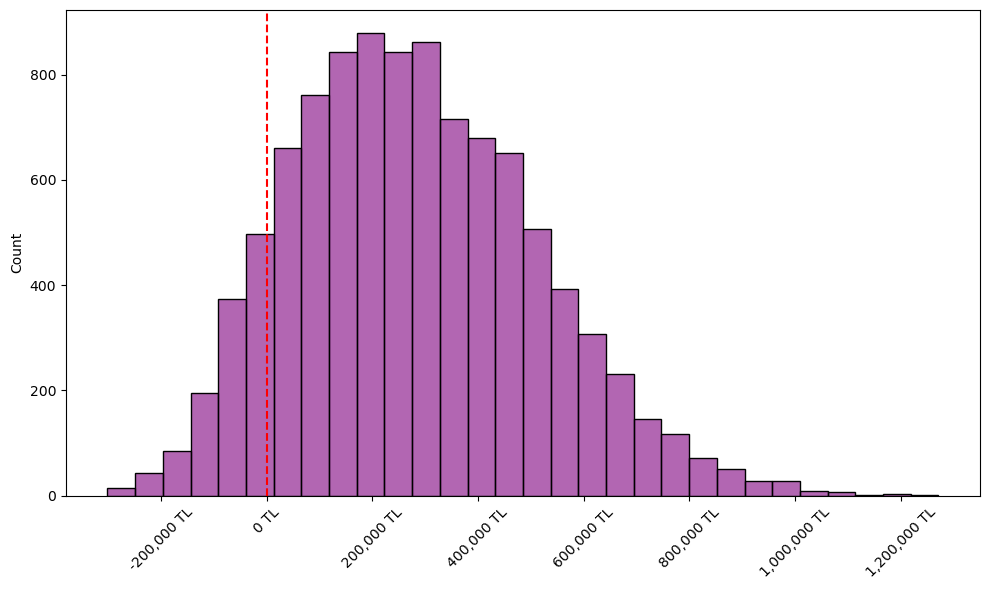

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(x=G, bins=30, color="purple", alpha=0.6)

def format_func(x, pos):
    return f'{x:,.0f} TL'

plt.gca().xaxis.set_major_formatter(FuncFormatter(format_func))
plt.xticks(rotation=45)
plt.tight_layout()
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

## Simulation Results and Risk Analysis

Following the Monte Carlo simulation of 10,000 iterations for the new product launch, the following key metrics were observed:

### 1. Deterministic vs. Probabilistic Comparison
* **Deterministic (Static) Profit:** 283,333.33 TL
* **Average Simulated Profit:** 280,938.17 TL
* **Observation:** The deterministic model often misses the "tails" of the distribution. The simulation provides a more realistic range of expected outcomes by accounting for price and cost volatility.

### 2. Risk Metrics
* **Probability of Loss:** 10.63%
* **Probability of Reaching Target (250k+ TL):** 52.11%
* **Insight:** While the average profit is positive, there is a measurable risk of ending in a deficit, which a single-point estimate would have completely overlooked.

### 3. Value at Risk (VaR) and Confidence Intervals
* **5th Percentile (Value at Risk):** -64,388.37 TL
* **95th Percentile (Upper Bound):** 682,392.34 TL
* **Analysis:** With 95% confidence, we can state that the project's profit will be at least the 5th percentile value. The wide range between the 5th and 95th percentiles reflects the uncertainty in sales volume and production costs.

### 4. Conclusion
The simulation indicates that the product launch is likely to be profitable. However, the **Value at Risk** suggests that management should prepare a contingency plan for a worst-case scenario where raw material costs (Triangular Distribution) hit their maximum while sales volume stays below the mean.